# Imports

In [3]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_silver_data

# Carregamento dos dados

In [4]:
sys.path.append(os.path.abspath('../'))

df = load_silver_data()

df['olist_orders_dataset'].head()

Buscando arquivos em: /home/paulo/Área de trabalho/work/bigada_e_Commerce/BigDataECommerce/data/silver
 -> olist_order_items_dataset carregado. (112545 linhas)
 -> product_category_name_translation carregado. (72 linhas)
 -> olist_products_dataset carregado. (32946 linhas)
 -> olist_order_reviews_dataset carregado. (98410 linhas)
 -> olist_geolocation_dataset carregado. (1000121 linhas)
 -> olist_customers_dataset carregado. (99441 linhas)
 -> olist_order_payments_dataset carregado. (103877 linhas)
 -> olist_sellers_dataset carregado. (3095 linhas)
 -> olist_orders_dataset carregado. (99441 linhas)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,is_delivered,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,True,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,True,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,True,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,True,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,True,False


# Insights

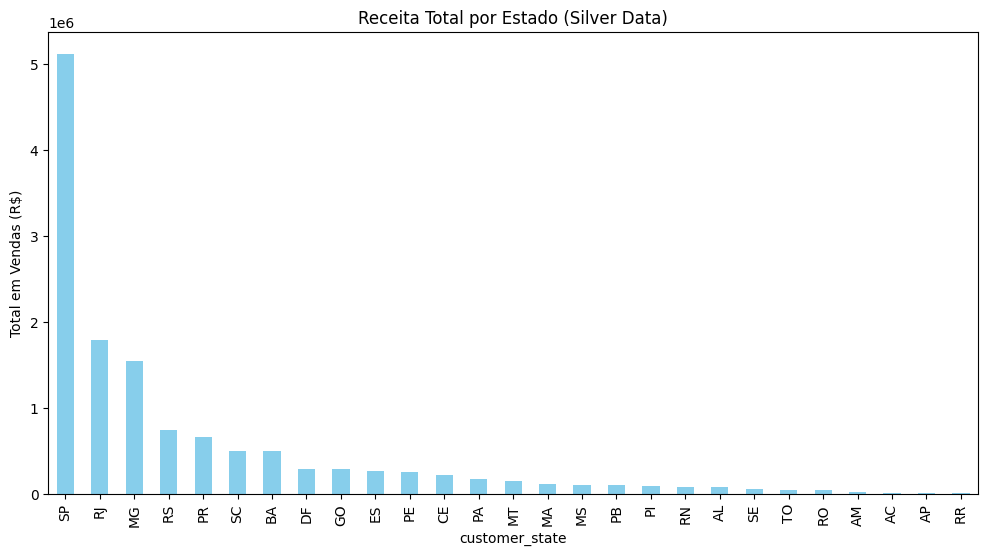

In [5]:
df_vendas = df['olist_order_items_dataset'].merge(df['olist_orders_dataset'], on='order_id')
df_vendas = df_vendas.merge(df['olist_customers_dataset'], on='customer_id')

receita_estado = df_vendas.groupby('customer_state')['price'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
receita_estado.plot(kind='bar', color='skyblue')
plt.title('Receita Total por Estado (Silver Data)')
plt.ylabel('Total em Vendas (R$)')
plt.show()

## Relação entre Tempo Estimado x Tempo Real

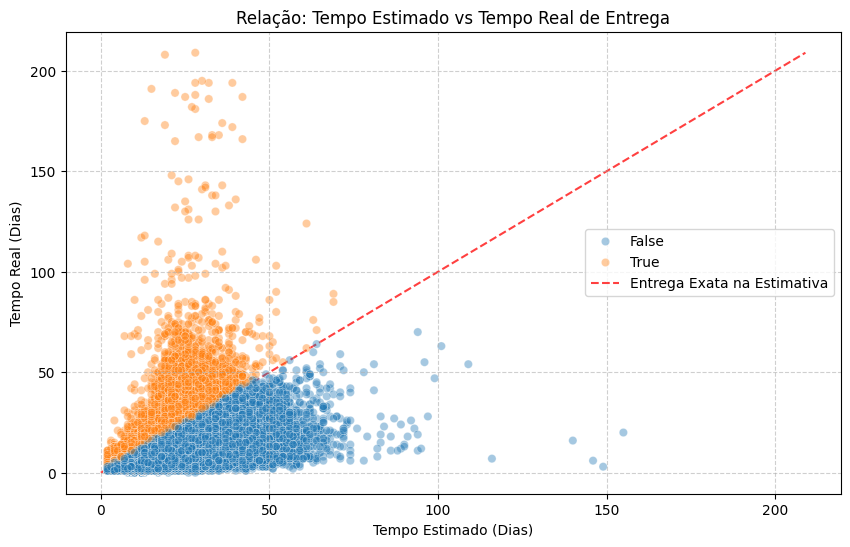

In [7]:
df_orders = df['olist_orders_dataset'].copy()

cols_data = [
    'order_purchase_timestamp', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]

for col in cols_data:
    df_orders[col] = pd.to_datetime(df_orders[col])

df_orders['tempo_real_dias'] = (
    df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']
).dt.days

df_orders['tempo_estimado_dias'] = (
    df_orders['order_estimated_delivery_date'] - df_orders['order_purchase_timestamp']
).dt.days

df_clean = df_orders.dropna(subset=['tempo_real_dias', 'tempo_estimado_dias'])

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean, 
    x='tempo_estimado_dias', 
    y='tempo_real_dias', 
    hue='is_late',
    alpha=0.4
)

lims = [0, max(df_clean['tempo_estimado_dias'].max(), df_clean['tempo_real_dias'].max())]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Entrega Exata na Estimativa')

plt.title('Relação: Tempo Estimado vs Tempo Real de Entrega')
plt.xlabel('Tempo Estimado (Dias)')
plt.ylabel('Tempo Real (Dias)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_15600/609109228.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


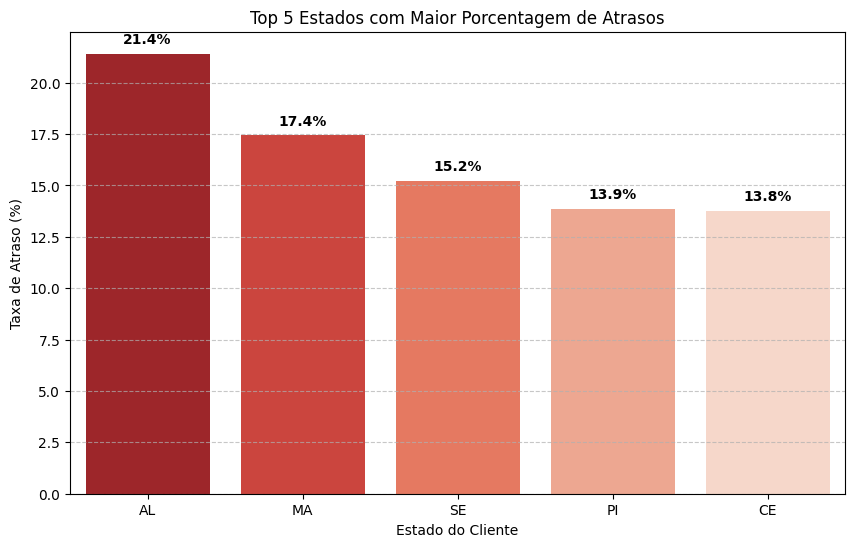

Resumo dos Top 5 Estados Críticos:
                total_pedidos  taxa_atraso_%
customer_state                              
AL                        397      21.410579
MA                        717      17.433752
SE                        335      15.223881
PI                        476      13.865546
CE                       1279      13.760751


In [8]:
df_geo_orders = pd.merge(
    df_clean, 
    df['olist_customers_dataset'][['customer_id', 'customer_state']], 
    on='customer_id'
)

atrasos_por_estado = df_geo_orders.groupby('customer_state').agg(
    total_pedidos=('is_late', 'count'),
    total_atrasos=('is_late', 'sum')
)

atrasos_por_estado['taxa_atraso_%'] = (atrasos_por_estado['total_atrasos'] / atrasos_por_estado['total_pedidos']) * 100

top_5_atrasos = atrasos_por_estado[atrasos_por_estado['total_pedidos'] > 100].sort_values('taxa_atraso_%', ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_5_atrasos.index, 
    y=top_5_atrasos['taxa_atraso_%'], 
    palette='Reds_r'
)

plt.title('Top 5 Estados com Maior Porcentagem de Atrasos')
plt.ylabel('Taxa de Atraso (%)')
plt.xlabel('Estado do Cliente')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(top_5_atrasos['taxa_atraso_%']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.show()

print("Resumo dos Top 5 Estados Críticos:")
print(top_5_atrasos[['total_pedidos', 'taxa_atraso_%']])

<h3>Eficiência da estimativa</h3>
<strong>Insight:</strong> A Olist é altamente conservadora em suas promessas. O sistema de frete calcula prazos longos para garantir que a maioria das entregas ocorra antes do limite prometido. Isso gera o "efeito surpresa positiva" no cliente, mas pode desencorajar vendas se o prazo exibido no checkout for longo demais sem necessidade.

<h3>Identificação de atrasos graves</h3>
<strong>Insight:</strong> Existem casos em que o tempo estimado era baixo (ex: 20 dias) e o tempo real passou de 100 ou 150 dias. Esses são os casos de falha crítica (extravios, greves ou problemas graves na transportadora).

<h3>Teto de entrega VS Realidade</h3>
<strong>Insight:</strong> O modelo de estimativa da Olist raramente projeta entregas para mais de 60-70 dias, mas a realidade logística (eixo Y) mostra que o "teto" real de entrega pode chegar a 200 dias em casos extremos. Isso indica que, para entregas de distância muito longa ou áreas de risco, o modelo de predição perde a acurácia.

<h3>Concentração de performance</h3>
<strong>Insight:</strong> A maioria dos clientes recebe seus produtos em aproximadamente metade do tempo prometido. Isso sugere uma folga (buffer) de segurança muito grande na estratégia de marketing de frete.